# Introduction

This notebook walks throught the production of Fig. 01, which plots significant wave height and Stokes drift from the four main WW3 simulations for a representative model snapshot.

## imports

In [8]:
import sys
sys.path.append("../src")

In [17]:
%load_ext autoreload
%autoreload 2

from pathlib import Path

import numpy as np
import xarray as xr
import matplotlib.pyplot as plt

from map_plot import (
    subset,
    add_arrow_to_axis,
    add_box_to_axis,
    add_circle_to_axes,
    make_four_panel_money_figure,
)

plt.rcdefaults()
plt.style.use("../src/paper.mplstyle")

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


# Data

We use the raw WAVEWATCH III (WW3) output to plot these maps.

In [10]:
BASE_PATH = Path('../data/raw_ww3/')

In [24]:
ww3_lvwd = xr.open_dataset(BASE_PATH / 'lvwd.nc')
ww3_hvwd = xr.open_dataset(BASE_PATH / 'hvwd.nc')
ww3_lvwd_cur = xr.open_dataset(BASE_PATH / 'lvwd_cur.nc')
ww3_hvwd_cur = xr.open_dataset(BASE_PATH / 'hvwd_cur.nc')

November 30, 2020 at 16:00 UTC was found to demonstrate wind- and current-driven variability in the Stokes drift very effectively. The spatial extent is nearly as large as the model domain, but is square, which is better for plotting.

In [25]:
timestep = '2020-11-30T16:00:00.000000000'

lons = slice(None, 240)
lats = slice(25, 45)

In [26]:
ww3_lvwd_plt = subset(ww3_lvwd, timestep, lons, lats)
ww3_hvwd_plt = subset(ww3_hvwd, timestep, lons, lats)
ww3_lvwd_cur_plt = subset(ww3_lvwd_cur, timestep, lons, lats)
ww3_hvwd_cur_plt = subset(ww3_hvwd_cur, timestep, lons, lats)

We close the full datasets to be kind to our workstation memory.

In [27]:
ww3_lvwd.close(); del ww3_lvwd
ww3_hvwd.close(); del ww3_hvwd
ww3_lvwd_cur.close(); del ww3_lvwd_cur

# Variables to Plot

We compute and extract the relevant variables for Fig. 03: Stokes drift magnitude (in cm/s) and significant wave height, $H_s$.

In [28]:
# Surface Stokes-drift magnitudes in m/s
us_lvwd_plt = np.hypot(
    ww3_lvwd_plt["uuss"],
    ww3_lvwd_plt["vuss"],
) * 100

us_hvwd_plt = np.hypot(
    ww3_hvwd_plt["uuss"],
    ww3_hvwd_plt["vuss"],
) * 100

us_lvwd_cur_plt = np.hypot(
    ww3_lvwd_cur_plt["uuss"],
    ww3_lvwd_cur_plt["vuss"],
) * 100

us_hvwd_cur_plt = np.hypot(
    ww3_hvwd_cur_plt["uuss"],
    ww3_hvwd_cur_plt["vuss"],
) * 100

Hs_lvwd_plt = ww3_lvwd_plt['hs']
Hs_hvwd_plt = ww3_hvwd_plt['hs']
Hs_lvwd_cur_plt = ww3_lvwd_cur_plt['hs']
Hs_hvwd_cur_plt = ww3_hvwd_cur_plt['hs']

# Plotting

To plot a figure with the standardized functions, we define a few dictionaries/lists:
1) Figure ranges: this sets the plotting range and levels, ticks for the colorbar, and extend of the colorbar (`both` = arrow on both sides)
2) Column titles: this specific function accepts a list of names for the columns that is plotted just on the first row (since the same model is plotted for each column)
3) Panels: this defines the layout of each row of 4 panels, set's their title (if we don't define column titles), and defines their "style". Style must be the same name as in `map_plot.py` and as the figure ranges (this should be fixed). The colorbar title and colormap are fixed in `map_plot.py` so that the same variable uses the same colormap across figures, but the ranges can be adjusted figure-by-figure to reveal the desired features.

In [29]:
figure_ranges = {
    "hs": {
        "levels": np.linspace(1, 6, 30),
        "ticks": [1.5, 3.5, 5.5],
        "extend": "both",
    },
    "stokes": {
        "levels": np.linspace(5, 23, 30), # "levels": np.linspace(5, 21, 30),
        "ticks": [6,14,22],        #"ticks": [6, 13, 20],
        "extend": "both",
    },
}

In [30]:
column_titles = [
    "WW3-LVWD",
    "WW3-HVWD",
    "WW3-LVWD&CUR",
    "WW3-HVWD&CUR",
]

In [35]:
Us_panels = [
    {
        "data": us_lvwd_plt,
        "title": r"$U_s$ from LVWD",
        "style": "stokes",
    },
    {
        "data": us_hvwd_plt,
        "title": r"$U_s$ from HVWD",
        "style": "stokes",
    },
    {
        "data": us_lvwd_cur_plt,
        "title": r"$U_s$ from LVWD&CUR",
        "style": "stokes",
    },
    {
        "data": us_hvwd_cur_plt,
        "title": r"$U_s$ from HVWD&CUR",
        "style": "stokes",
    },
]

In [36]:
Hs_panels = [
    {
        "data": Hs_lvwd_plt,
        "title": r"$H_s$ from LVWD",
        "style": "hs",
    },
    {
        "data": Hs_hvwd_plt,
        "title": r"$H_s$ from HVWD",
        "style": "hs",
    },
    {
        "data": Hs_lvwd_cur_plt,
        "title": r"$H_s$ from LVWD&CUR",
        "style": "hs",
    },
    {
        "data": Hs_hvwd_cur_plt,
        "title": r"$H_s$ from HVWD&CUR",
        "style": "hs",
    },
]

The order of the panels in `four_panel_rows` determines their order in the figure.

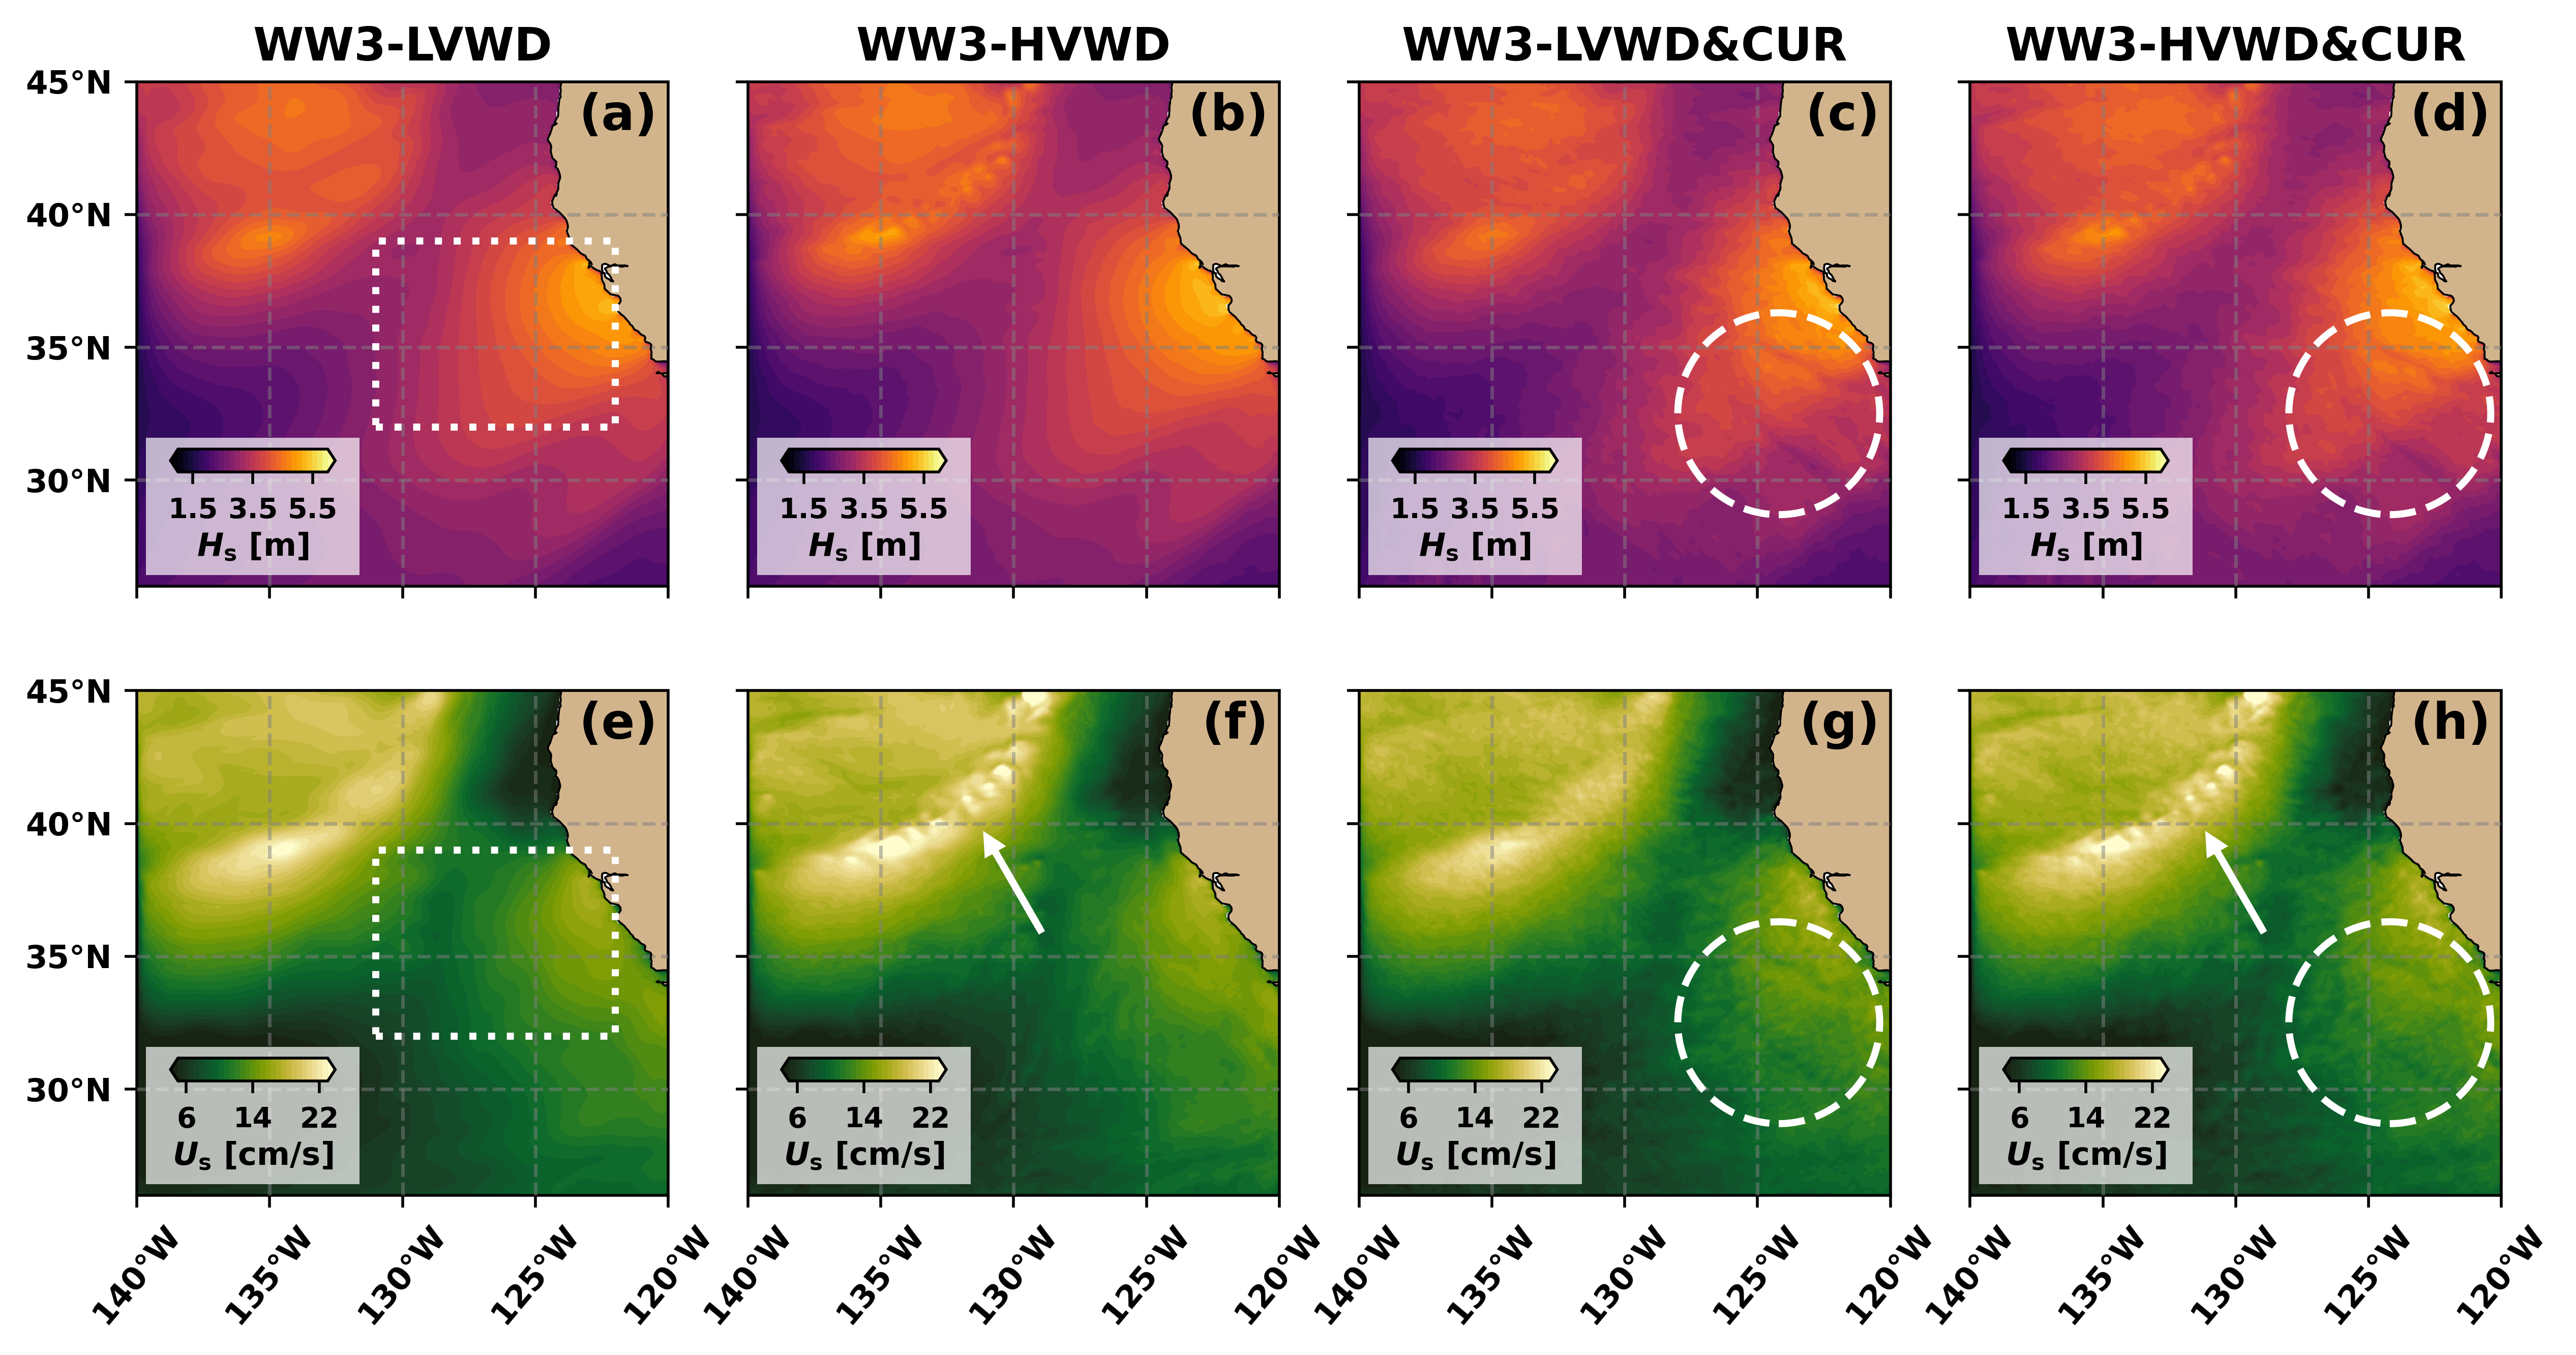

In [38]:
fig, axes = make_four_panel_money_figure(
    four_panel_rows=[
        Hs_panels,
        Us_panels,
    ],
    ranges=figure_ranges,
    column_titles=column_titles,
    extent=[-140, -120, 26, 45],
    hspace = -0.2,
)

# Annotation: adds a circle to highlight a CEW-driven feature
add_circle_to_axes(axes[0][2], center_lon=235.8, center_lat=32.5, radius=3.8)
add_circle_to_axes(axes[0][3], center_lon=235.8, center_lat=32.5, radius=3.8)
add_circle_to_axes(axes[1][2], center_lon=235.8, center_lat=32.5, radius=3.8)
add_circle_to_axes(axes[1][3], center_lon=235.8, center_lat=32.5, radius=3.8)

# Annotation: points out HVWD-driven feature in the Stokes drift
add_arrow_to_axis(axes[1][1], lat=36, lon=231, length=4, angle=120)
add_arrow_to_axis(axes[1][3], lat=36, lon=231, length=4, angle=120)

# Spectral analysis domain
add_box_to_axis(
    axes[0][0],
    lon_min=-131,
    lon_max=-122,
    lat_min=32,
    lat_max=39,
)

add_box_to_axis(
    axes[1][0],
    lon_min=-131,
    lon_max=-122,
    lat_min=32,
    lat_max=39,
)

# The title font is adjusted for this figure to be more visible
for row in axes:
    for ax in row:
        ax.title.set_fontsize(13)
        ax.title.set_fontweight("bold")
        
plt.show()

We save the figure at a high DPI.

In [39]:
fig.savefig(
    '../figures/fig03.png',
    dpi=500,
    bbox_inches='tight',
    pad_inches=0.1,
)